In [ ]:
pip install tensorflow opencv-python numpy


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set your dataset directory path in Google Drive
train_dir = '/content/drive/My Drive/Dataset/train'
validation_dir = '/content/drive/My Drive/Dataset/valid'
test_dir = '/content/drive/My Drive/Dataset/test'

# Set image parameters
image_size = (224, 224)  # You can adjust this based on your model requirements
batch_size = 32

# Create data generators
train_datagen = ImageDataGenerator(rescale=1.0/255)
validation_datagen = ImageDataGenerator(rescale=1.0/255)
test_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary'  # Use 'categorical' if you have more than two classes
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary'
)


Found 267 images belonging to 2 classes.
Found 77 images belonging to 2 classes.
Found 38 images belonging to 2 classes.


In [ ]:
# Build the CNN model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(image_size[0], image_size[1], 3)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    epochs=10
)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 64s 8s/step - accuracy: 1.0000 - loss: 0.2010 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 168ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 36s 4s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 1.0000 - loss: 

In [ ]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_generator, steps=test_generator.samples // batch_size)
print(f'Test Accuracy: {test_accuracy:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00
Test Accuracy: 1.0000


In [ ]:
# Save the model
model.save('/content/drive/My Drive/path_to_save_model/CNN_debris_detection_model.h5')


In [ ]:
!pip install torch torchvision torchaudio
!pip install tensorflow
!pip install keras


In [ ]:
# Clone the YOLOv5 repository
!git clone https://github.com/ultralytics/yolov5

# Change to the YOLOv5 directory
%cd yolov5

# Install necessary dependencies
!pip install -r requirements.txt


Cloning into 'yolov5'...
remote: Enumerating objects: 16965, done.
remote: Counting objects: 100% (160/160), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 16965 (delta 79), reused 99 (delta 49), pack-reused 16805 (from 1)
Receiving objects: 100% (16965/16965), 15.71 MiB | 15.91 MiB/s, done.
Resolving deltas: 100% (11608/11608), done.
/content/yolov5/yolov5


In [ ]:
import os

# Change this to your local YOLOv5 path
os.chdir('/content/yolov5')  # If you're using Google Colab or adjust accordingly

# Run training
!python train.py --img 640 --batch 16 --epochs 15 --data /content/data.yaml --weights yolov5s.pt --cache

# The training process will display metrics including precision, recall, mAP50, and mAP50-95.



2024-09-30 14:33:50.321329: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-30 14:33:50.364232: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-30 14:33:50.376381: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
train: weights=yolov5s.pt, cfg=, data=/content/data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=15, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=ram, image_weights=False, device=, multi_scale=False, single_cls=Fals

Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip
YOLOv5 🚀 2024-9-30 Python-3.10.12 torch-2.4.1+cu121 CPU

Fusing layers... 
custom_YOLOv5s summary: 232 layers, 7246518 parameters, 0 gradients
Adding AutoShape... 
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


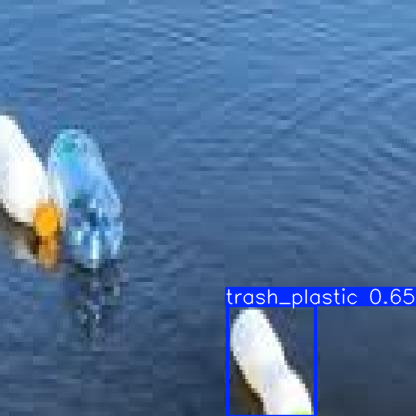

image 1/1: 416x416 1 trash_plastic
Speed: 11.9ms pre-process, 446.6ms inference, 1.1ms NMS per image at shape (1, 3, 640, 640)


In [ ]:
import torch
from PIL import Image
import os
import matplotlib.pyplot as plt

# Load the trained YOLOv5 model (replace the path with your best.pt file)
model = torch.hub.load('ultralytics/yolov5', 'custom', path='/content/best.pt', force_reload=True)

# Function to detect and visualize predictions
def detect_floating_trash(image_path):
    img = Image.open(image_path)  # Load the image
    results = model(img)           # Perform inference
    results.show()                 # Show the image with detections
    return results

# Test a single image (adjust path to your test image)
predictions = detect_floating_trash('/content/Dataset/Debris/101_jpg.rf.c63305f17e02d96d93a3d53f63221dc1.jpg')
print(predictions)  # Show predictions for the test image


In [ ]:
import torch
from PIL import Image
import os
import matplotlib.pyplot as plt

# Load the trained YOLOv5 model (replace the path with your best.pt file)
model = torch.hub.load('ultralytics/yolov5', 'custom', path='/content/best.pt', force_reload=True)

# Function to detect and visualize predictions
def detect_floating_trash(image_path):  # Removed conf_thresh
   img = Image.open(image_path)  # Load the image
   results = model(img)        # Perform inference without conf_thresh
   return results

# Define the path to your test images
test_images_dir = '/content/drive/MyDrive/Dataset/test/images'  # Adjust this path as needed

# Create an output directory to save detection results
output_dir = '/content/outputs/yolov5_test_output'
os.makedirs(output_dir, exist_ok=True)

# Loop through all images in the test dataset
for filename in os.listdir(test_images_dir):
   if filename.endswith(('.jpg', '.jpeg', '.png')):  # Check for valid image extensions
      img_path = os.path.join(test_images_dir, filename)
      print(f"Processing: {img_path}")

      # Perform inference
      results = detect_floating_trash(img_path)  # Use the updated function

      # Filter results based on confidence threshold
      # Set the confidence threshold you want (e.g., 0.25)
      results.pred[0] = results.pred[0][results.pred[0][:, 4] >= 0.25]  # Adjusting detections

      # Print the results to verify if detections are being made
      print(f"Results: {results}")

      # Save the image with detections
      save_path = os.path.join(output_dir, filename)
      print(f"Saving results to: {save_path}")
      results.save(save_path)  # Saves the image with detections

      print(f"Saved results for {filename} at {save_path}")

Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip
YOLOv5 🚀 2024-9-30 Python-3.10.12 torch-2.4.1+cu121 CPU

Fusing layers... 
custom_YOLOv5s summary: 232 layers, 7246518 parameters, 0 gradients
Adding AutoShape... 
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


Processing: /content/drive/MyDrive/Dataset/test/images/istockphoto-1559014674-612x612_jpg.rf.5ddf8425cfb60aebaf09015aea741f34.jpg


Saved 1 image to runs/detect/exp233


Results: image 1/1: 640x640 (no detections)
Speed: 8.1ms pre-process, 402.8ms inference, 0.5ms NMS per image at shape (1, 3, 640, 640)
Saving results to: /content/outputs/yolov5_test_output/istockphoto-1559014674-612x612_jpg.rf.5ddf8425cfb60aebaf09015aea741f34.jpg
Saved results for istockphoto-1559014674-612x612_jpg.rf.5ddf8425cfb60aebaf09015aea741f34.jpg at /content/outputs/yolov5_test_output/istockphoto-1559014674-612x612_jpg.rf.5ddf8425cfb60aebaf09015aea741f34.jpg
Processing: /content/drive/MyDrive/Dataset/test/images/0280_jpg.rf.b8b09b39dddba10162fc1474bf7eb2ff.jpg


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
Saved 1 image to runs/detect/exp234


...

Results: image 1/1: 640x640 (no detections)
Speed: 8.3ms pre-process, 625.3ms inference, 0.6ms NMS per image at shape (1, 3, 640, 640)
Saving results to: /content/outputs/yolov5_test_output/0313_jpg.rf.e7536f04aa8809b03aab9739c6ef7753.jpg
Saved results for 0313_jpg.rf.e7536f04aa8809b03aab9739c6ef7753.jpg at /content/outputs/yolov5_test_output/0313_jpg.rf.e7536f04aa8809b03aab9739c6ef7753.jpg
Processing: /content/drive/MyDrive/Dataset/test/images/istockphoto-946641538-612x612_jpg.rf.8cf325f5e74dba2de999c8a0e92bd782.jpg


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
Saved 1 image to runs/detect/exp269


Results: image 1/1: 640x640 2 trash_plastics
Speed: 9.0ms pre-process, 627.3ms inference, 1.6ms NMS per image at shape (1, 3, 640, 640)
Saving results to: /content/outputs/yolov5_test_output/istockphoto-946641538-612x612_jpg.rf.8cf325f5e74dba2de999c8a0e92bd782.jpg
Saved results for istockphoto-946641538-612x612_jpg.rf.8cf325f5e74dba2de999c8a0e92bd782.jpg at /content/outputs/yolov5_test_output/istockphoto-946641538-612x612_jpg.rf.8cf325f5e74dba2de999c8a0e92bd782.jpg
Processing: /content/drive/MyDrive/Dataset/test/images/istockphoto-647692316-612x612_jpg.rf.7d397fe2807391d730b31da5610cb393.jpg


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
Saved 1 image to runs/detect/exp270


Results: image 1/1: 640x640 1 trash_plastic
Speed: 8.4ms pre-process, 631.8ms inference, 1.5ms NMS per image at shape (1, 3, 640, 640)
Saving results to: /content/outputs/yolov5_test_output/istockphoto-647692316-612x612_jpg.rf.7d397fe2807391d730b31da5610cb393.jpg
Saved results for istockphoto-647692316-612x612_jpg.rf.7d397fe2807391d730b31da5610cb393.jpg at /content/outputs/yolov5_test_output/istockphoto-647692316-612x612_jpg.rf.7d397fe2807391d730b31da5610cb393.jpg
